# Khám phá dữ liệu (EDA) — hệ APS/APU

Notebook này đọc dữ liệu **đã được gộp** bởi `aps_apu_cleaner.py` (mỗi Log Type
1 file CSV trong thư mục `cleaned_data/`) và khám phá **chủ yếu bằng biểu đồ**,
đặc biệt là chuỗi thời gian, thay vì bảng số.

Dùng cột **`System`** (ví dụ `APU 1`, `APU 2`...) làm khóa để phân biệt các đơn
vị — không phụ thuộc cột `Unit`.

1. Tổng quan dữ liệu (biểu đồ)
2. Toàn cảnh nhiều ngày cùng lúc (heatmap ngày × giờ)
3. Chuỗi thời gian chi tiết
4. So sánh giữa các APU
5. Dòng thời gian sự kiện lỗi/cảnh báo
6. Tương quan giữa các biến

> **Trước khi chạy:** đặt notebook này cùng cấp với thư mục `cleaned_data/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import re

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

CLEANED_DIR = Path("cleaned_data")   # doi lai neu ban de o cho khac

def load_table(log_type_slug: str) -> pd.DataFrame:
    """Doc 1 bang da gop, vi du load_table('apu_stat_10s')"""
    path = CLEANED_DIR / f"{log_type_slug}.csv"
    return pd.read_csv(path, parse_dates=["TimeStamp"])

available = sorted(CLEANED_DIR.glob("*.csv"))
print(f"Co {len(available)} file trong {CLEANED_DIR.resolve()}")

Co 12 file trong C:\PV\cleaned_data


## 1. Tổng quan dữ liệu

Thay vì đọc bảng số, nhìn ngay số dòng và % thiếu dữ liệu của mỗi Log Type
bằng biểu đồ cột.

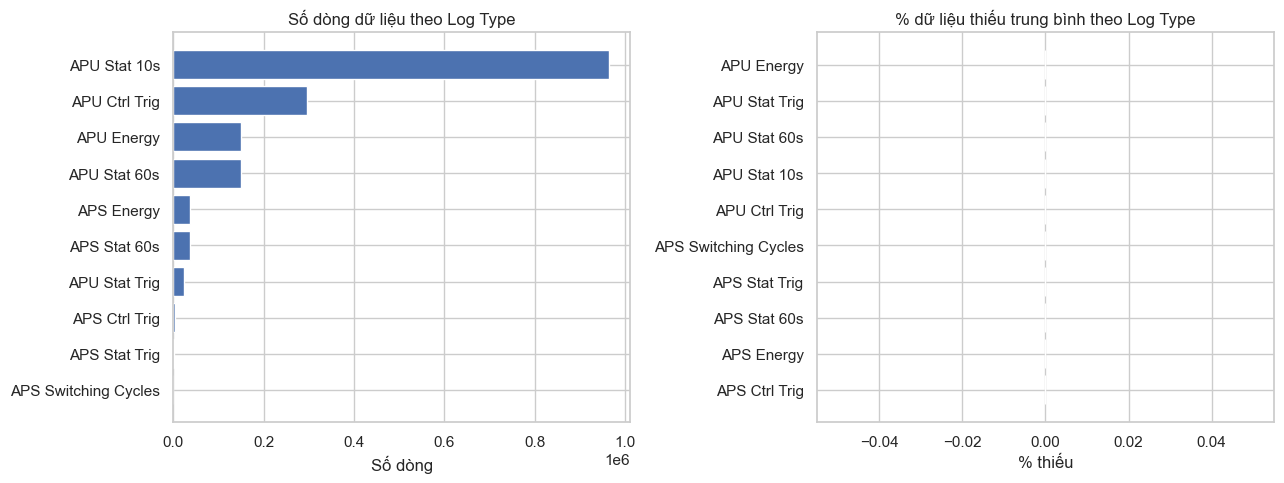

In [2]:
quality = pd.read_csv(CLEANED_DIR / "quality_report.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

order = quality.sort_values("So dong (tat ca cac file)", ascending=True)
axes[0].barh(order["Log Type"], order["So dong (tat ca cac file)"], color="#4C72B0")
axes[0].set_title("Số dòng dữ liệu theo Log Type")
axes[0].set_xlabel("Số dòng")

order2 = quality.sort_values("% thieu TB cac cot", ascending=True)
axes[1].barh(order2["Log Type"], order2["% thieu TB cac cot"], color="#DD8452")
axes[1].set_title("% dữ liệu thiếu trung bình theo Log Type")
axes[1].set_xlabel("% thiếu")

plt.tight_layout()
plt.show()

skipped_path = CLEANED_DIR / "skipped_files.csv"
if skipped_path.exists():
    n = len(pd.read_csv(skipped_path))
    print(f"[Lưu ý] {n} file đã bị bỏ qua khi gộp — xem skipped_files.csv để biết chi tiết.")

## 2. Toàn cảnh nhiều ngày cùng lúc — Heatmap ngày × giờ

Đây là cách trực quan nhất để nhìn **hàng chục ngày cùng lúc**: mỗi ô là công
suất DC trung bình (`Pdc/kW`) tại 1 giờ trong 1 ngày cụ thể. Ngày nào phát điện
tốt sẽ có dải màu đậm hình vòm rõ ràng ở giữa ngày; ngày nào nhạt/lệch là ngày
đáng chú ý (thời tiết xấu, lỗi thiết bị, thiếu dữ liệu...).

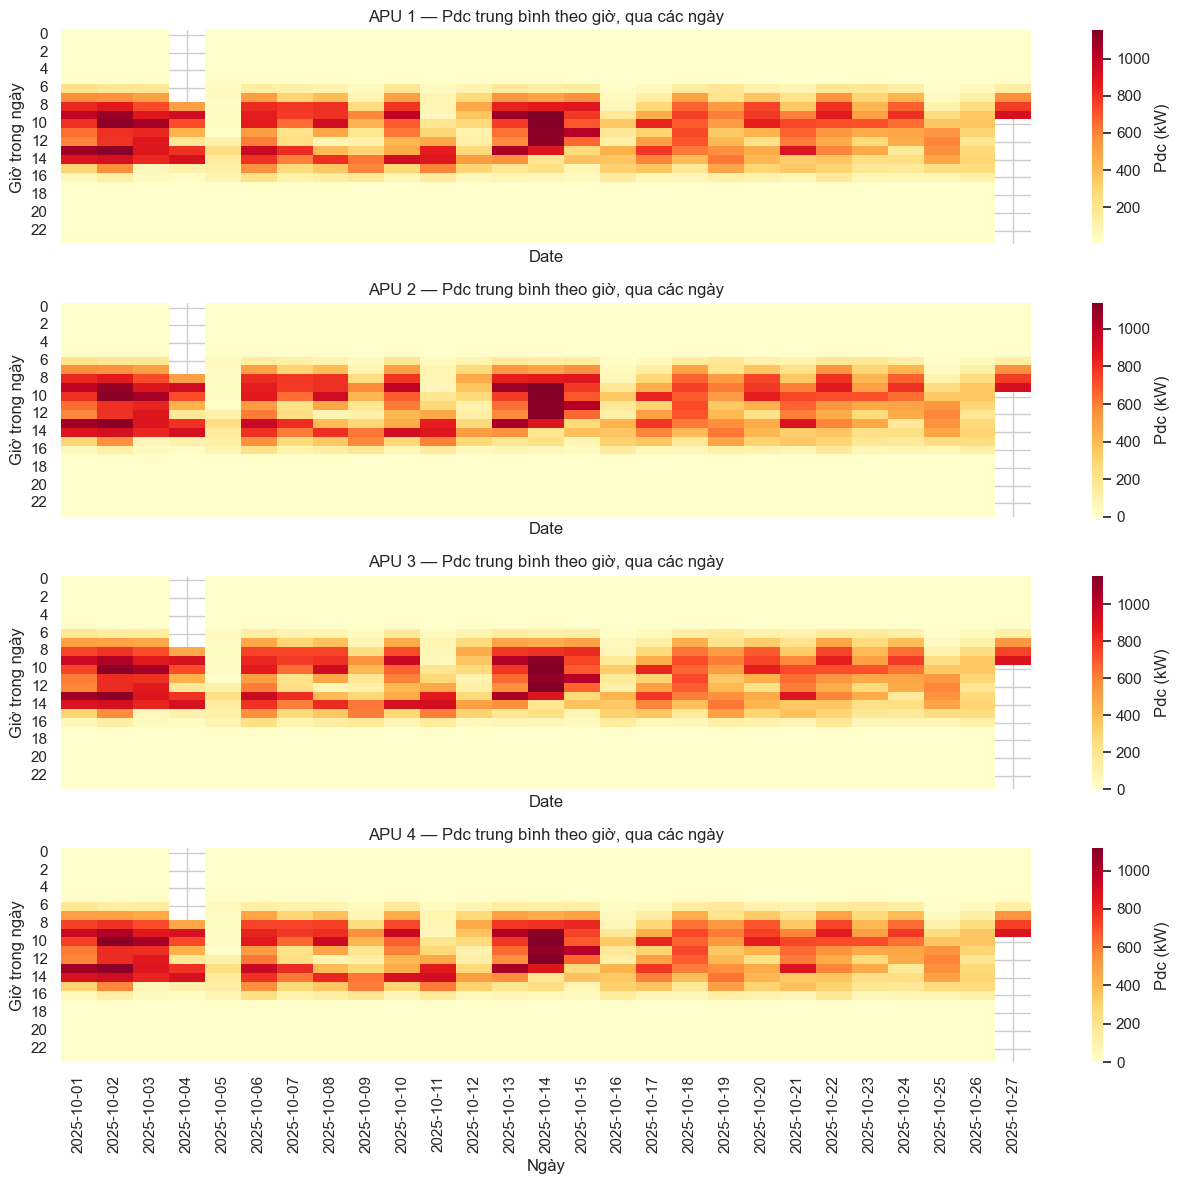

In [3]:
stat10s = load_table("apu_stat_10s")
stat10s["Date"] = stat10s["TimeStamp"].dt.date
stat10s["Hour"] = stat10s["TimeStamp"].dt.hour

systems = sorted(stat10s["System"].unique())

fig, axes = plt.subplots(len(systems), 1, figsize=(13, 3 * len(systems)), sharex=True)
if len(systems) == 1:
    axes = [axes]

for ax, sysname in zip(axes, systems):
    sub = stat10s[stat10s["System"] == sysname]
    pivot = sub.pivot_table(index="Hour", columns="Date", values="Pdc/kW", aggfunc="mean")
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Pdc (kW)"})
    ax.set_title(f"{sysname} — Pdc trung bình theo giờ, qua các ngày")
    ax.set_ylabel("Giờ trong ngày")

axes[-1].set_xlabel("Ngày")
plt.tight_layout()
plt.show()

## 3. Chuỗi thời gian chi tiết

**3 ngày đầu** — xem hình dạng chi tiết theo từng phút/giây, tất cả các System
chồng lên nhau trên cùng 1 trục thời gian.

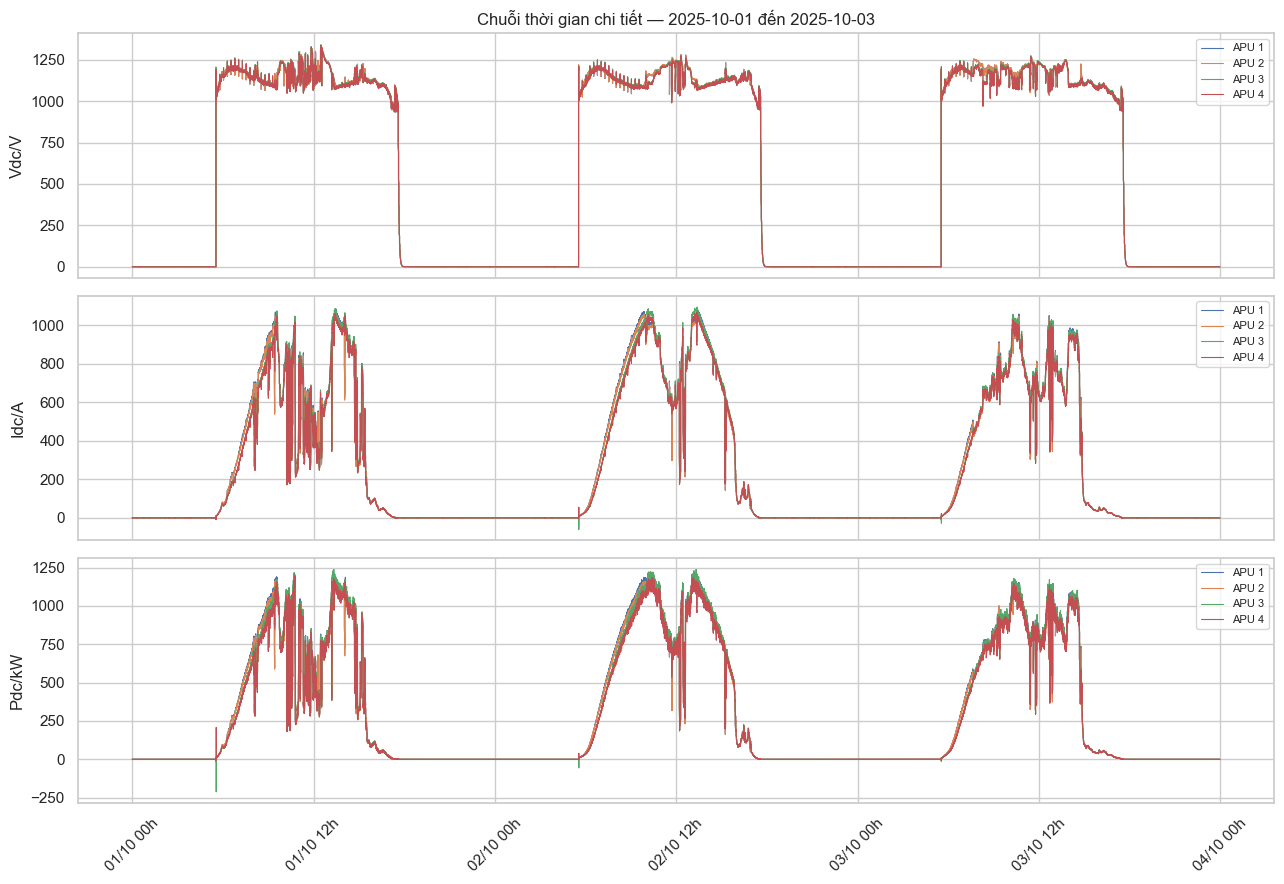

In [4]:
first_days = sorted(stat10s["Date"].unique())[:3]
subset = stat10s[stat10s["Date"].isin(first_days)]

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, col in zip(axes, ["Vdc/V", "Idc/A", "Pdc/kW"]):
    for sysname, g in subset.groupby("System"):
        ax.plot(g["TimeStamp"], g[col], label=sysname, linewidth=0.8)
    ax.set_ylabel(col)
    ax.legend(loc="upper right", fontsize=8)
axes[0].set_title(f"Chuỗi thời gian chi tiết — {first_days[0]} đến {first_days[-1]}")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d/%m %Hh"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Toàn bộ giai đoạn** — công suất trung bình mỗi ngày, kèm dải min–max để
thấy độ biến động trong ngày, không chỉ giá trị trung bình.

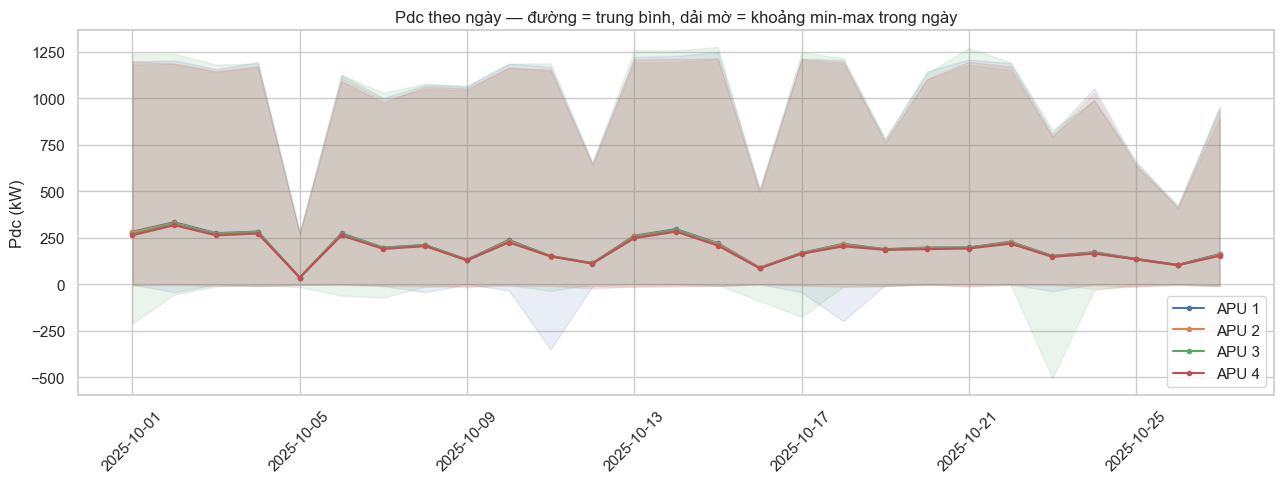

In [5]:
daily = (stat10s.groupby(["Date", "System"])["Pdc/kW"]
                 .agg(["mean", "min", "max"])
                 .reset_index())

fig, ax = plt.subplots(figsize=(13, 5))
palette = sns.color_palette(n_colors=len(systems))
for color, sysname in zip(palette, systems):
    g = daily[daily["System"] == sysname]
    ax.plot(g["Date"], g["mean"], marker="o", markersize=3, label=sysname, color=color)
    ax.fill_between(g["Date"], g["min"], g["max"], alpha=0.12, color=color)

ax.set_title("Pdc theo ngày — đường = trung bình, dải mờ = khoảng min-max trong ngày")
ax.set_ylabel("Pdc (kW)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. So sánh giữa các APU

Violin plot cho thấy cả hình dạng phân phối (không chỉ trung vị/khoảng như
boxplot) — dễ thấy System nào có phân phối lệch khác hẳn.

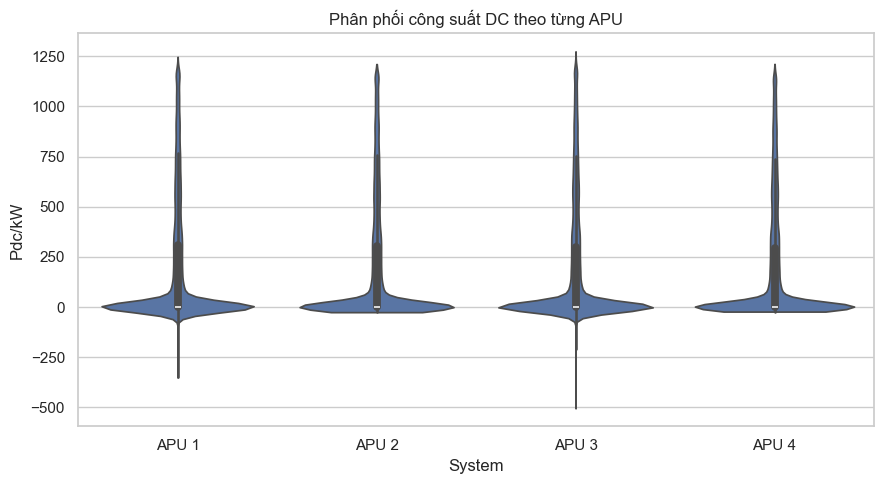

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(data=stat10s, x="System", y="Pdc/kW", ax=ax, cut=0)
ax.set_title("Phân phối công suất DC theo từng APU")
plt.tight_layout()
plt.show()

## 5. Dòng thời gian sự kiện lỗi/cảnh báo

Mỗi chấm là 1 lần một mã Error/Warning được kích hoạt — nhìn theo trục thời
gian để thấy sự kiện có dồn vào giai đoạn nào không, và bar chart tổng số sự
kiện theo ngày.

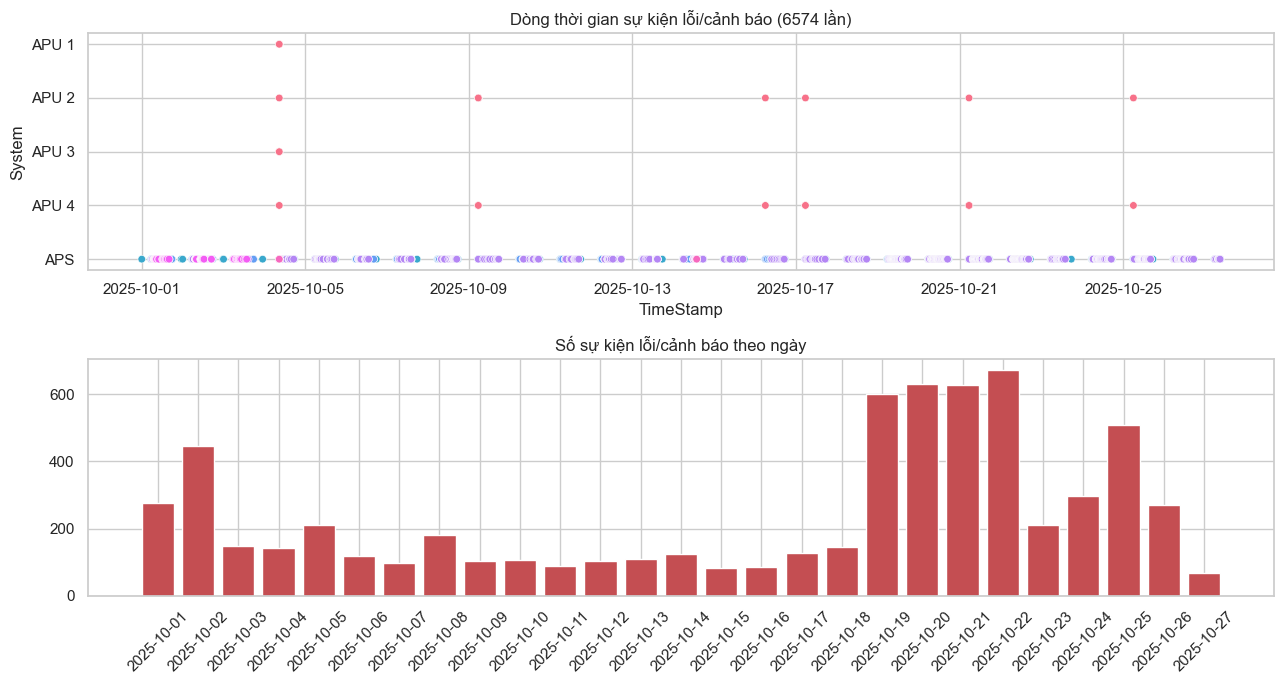

In [7]:
def extract_events(df: pd.DataFrame) -> pd.DataFrame:
    """Tra ve cac dong co Error*/Warning* != 0, dang long format de ve."""
    event_cols = [c for c in df.columns if re.match(r"^(Error|Warning)\d+$", c)]
    if not event_cols:
        return pd.DataFrame()
    long = df.melt(id_vars=["System", "TimeStamp"], value_vars=event_cols,
                    var_name="Loai su kien", value_name="Gia tri")
    return long[long["Gia tri"] != 0]

all_events = []
for slug, label in [("apu_stat_trig", "APU"), ("aps_stat_trig", "APS")]:
    path = CLEANED_DIR / f"{slug}.csv"
    if not path.exists():
        continue
    df = load_table(slug)
    ev = extract_events(df)
    if len(ev):
        ev["Nguon"] = label
        all_events.append(ev)

if all_events:
    events = pd.concat(all_events, ignore_index=True)

    fig, axes = plt.subplots(2, 1, figsize=(13, 7))

    sns.scatterplot(data=events, x="TimeStamp", y="System", hue="Loai su kien",
                     ax=axes[0], s=30, legend=False)
    axes[0].set_title(f"Dòng thời gian sự kiện lỗi/cảnh báo ({len(events)} lần)")

    events["Date"] = events["TimeStamp"].dt.date
    daily_counts = events.groupby("Date").size()
    axes[1].bar(daily_counts.index.astype(str), daily_counts.values, color="#C44E52")
    axes[1].set_title("Số sự kiện lỗi/cảnh báo theo ngày")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Không có sự kiện Error/Warning nào được ghi nhận trong dữ liệu này.")

## 6. Tương quan giữa các biến

Ghép nhiệt độ (`APU Stat 60s`) với công suất (`APU Stat 10s`) theo `System` +
thời gian gần nhất, rồi xem tương quan bằng scatter (có đường hồi quy) và
heatmap — đặc biệt để kiểm tra hiện tượng suy giảm công suất khi quá nhiệt.

In [8]:
stat60s = load_table("apu_stat_60s")

merged_parts = []
for sysname in systems:
    left = stat10s[stat10s["System"] == sysname].sort_values("TimeStamp")
    right = stat60s[stat60s["System"] == sysname].sort_values("TimeStamp")
    if left.empty or right.empty:
        continue
    m = pd.merge_asof(left, right, on="TimeStamp", direction="nearest",
                       tolerance=pd.Timedelta("60s"), suffixes=("", "_60s"))
    merged_parts.append(m)

merged = pd.concat(merged_parts, ignore_index=True) if merged_parts else pd.DataFrame()
print("Số dòng sau khi ghép:", len(merged))

Số dòng sau khi ghép: 963845


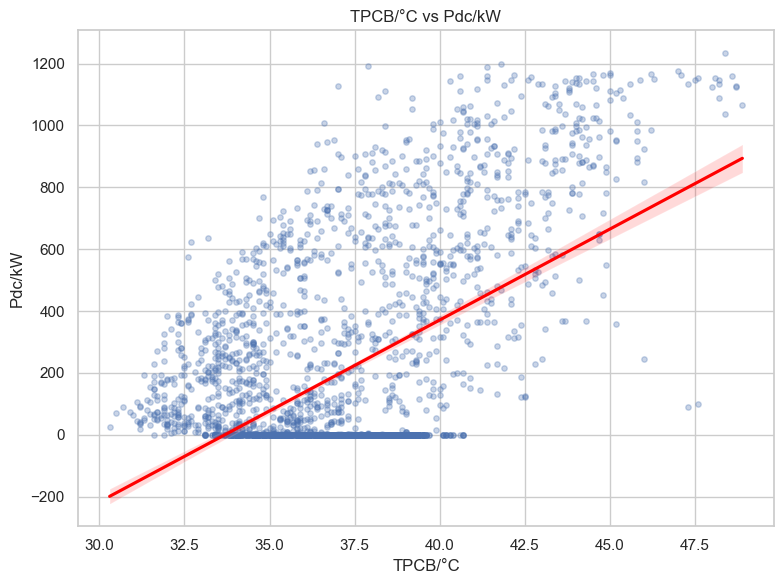

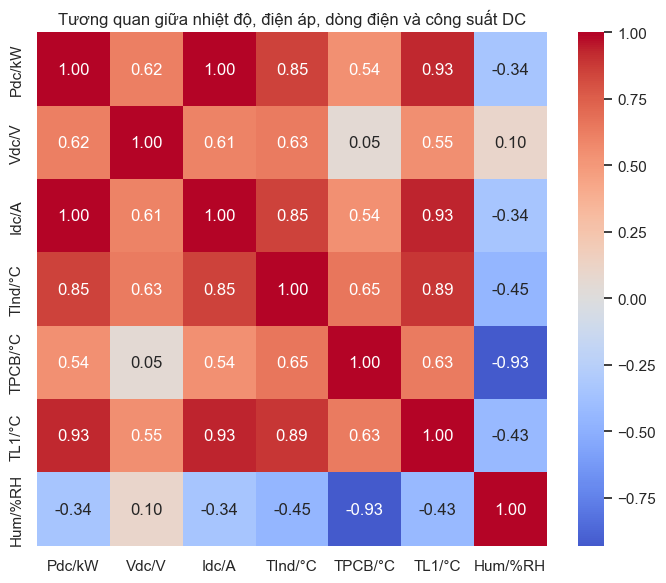

In [9]:
temp_col = next((c for c in ["TPCB/°C", "TInd/°C", "TL1/°C"] if c in merged.columns), None)

if len(merged) and temp_col:
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.regplot(data=merged.sample(min(3000, len(merged)), random_state=0),
                x=temp_col, y="Pdc/kW", ax=ax,
                scatter_kws={"alpha": 0.3, "s": 15}, line_kws={"color": "red"})
    ax.set_title(f"{temp_col} vs Pdc/kW")
    plt.tight_layout()
    plt.show()

corr_cols = [c for c in ["Pdc/kW", "Vdc/V", "Idc/A", "TInd/°C", "TPCB/°C", "TL1/°C", "Hum/%RH"]
             if c in merged.columns]
if len(merged) and len(corr_cols) > 1:
    corr = merged[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title("Tương quan giữa nhiệt độ, điện áp, dòng điện và công suất DC")
    plt.tight_layout()
    plt.show()

## Tổng kết & bước tiếp theo

Nhìn lại các biểu đồ trên và ghi chú lại:

- **Mục 2 (heatmap ngày×giờ):** ngày nào "nhạt màu"/lệch hình vòm bất thường?
- **Mục 4 (violin plot):** System nào có phân phối công suất khác hẳn 3 cái còn lại?
- **Mục 5 (dòng thời gian sự kiện):** lỗi/cảnh báo có dồn vào 1 giai đoạn cụ thể không?
- **Mục 6 (tương quan):** nhiệt độ có tương quan âm rõ với Pdc không (dấu hiệu derating)?

Từ đây bạn hình thành câu hỏi nghiên cứu cụ thể để trình bày với cô, ví dụ:
*"Nhiệt độ PCB ảnh hưởng thế nào đến hiệu suất chuyển đổi DC-AC của APU X?"*